##Breast Cancer Classification Using Logistic Regression

📌 **Introduction**

Breast cancer is one of the most common types of cancer worldwide. Early detection plays a critical role in improving survival rates and treatment effectiveness. Machine learning techniques can assist in medical diagnosis by identifying patterns in medical data that may not be immediately obvious to humans.

In this project, the Breast Cancer Wisconsin dataset is used to build a classification model that predicts whether a tumor is benign or malignant based on diagnostic measurements. The objective is to develop a reliable model that can assist healthcare professionals in estimating the probability of malignancy.

## Dataset Description

The dataset used in this project contains features computed from digitized images of breast mass samples. These features describe characteristics such as radius, texture, perimeter, area, and smoothness.

The target variable indicates whether the tumor is:
- 0 → Malignant (cancerous)
- 1 → Benign (non-cancerous)

This dataset is widely used for classification tasks in machine learning.

In [91]:
#drive mounting
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
#import pandas library
import pandas as pd

In [93]:
#navigate and load the dataset
file_path = "/content/drive/MyDrive/Data Science Projects/LAB Tasks/Breast_Cancer(Easy).csv"
df = pd.read_csv(file_path)

In [94]:
#display the first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [95]:
#display statistical summary of the dataset
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [96]:
#check data shape
df.shape

(569, 33)

In [97]:
#inspect columns
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

**Data Structure Inspection**

The dataset initially contains 569 observations and 33 columns.
Upon inspection of the column names, I observed:

-- An id column (non-informative for prediction)

-- A diagnosis column (target variable)

-- An Unnamed: 32 column (empty / irrelevant)

-- 30 numerical feature columns extracted from digitized breast mass images.

Since id and Unnamed: 32 do not contribute to predictive modeling, they will be removed.

In [98]:
#remove "id" and "Unnamed" column
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

In [99]:
df.shape

(569, 31)

In [100]:
#display summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [101]:
#re-confirm null/missing values
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


**Data Integrity Check**

The dataset contains 569 observations and 31 columns after removing irrelevant features.
Inspection shows:

-- 30 numerical features (float64)

-- 1 categorical target variable (diagnosis)

-- No missing values in any column

Since there are no null values and all predictors are numerical, the dataset is structurally clean and ready for preprocessing.

In [102]:
#Target variable inspection
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [103]:
df['diagnosis'].value_counts()
df['diagnosis'].value_counts(normalize=True)

,proportion
diagnosis,
B,0.627417
M,0.372583


**Target Class Distribution**

The dataset contains 62.7% benign cases and 37.3% malignant cases.
Although the dataset is slightly imbalanced, the imbalance is not extreme.

In medical diagnosis problems, special attention must be given to detecting malignant cases. Therefore, evaluation metrics such as recall for the malignant class will be particularly important in model assessment.

/tmp/ipykernel_7775/3270570143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


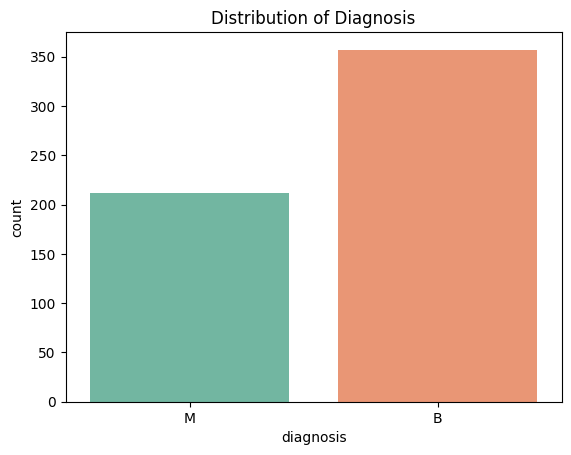

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title("Distribution of Diagnosis")
plt.show()

**Class Imbalance Insight**

The dataset shows a moderate class imbalance: 62.7% benign and 37.3% malignant cases.
Although the imbalance is not extreme, special care must be taken to correctly identify malignant tumors.

Evaluation will focus on metrics such as recall and F1-score for the malignant class, rather than relying solely on overall accuracy.

In [105]:
#Encoding the Target Variable values
df['diagnosis'] = df['diagnosis'].map({'B':0, 'M':1})
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [106]:
df.groupby('diagnosis').mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
1,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


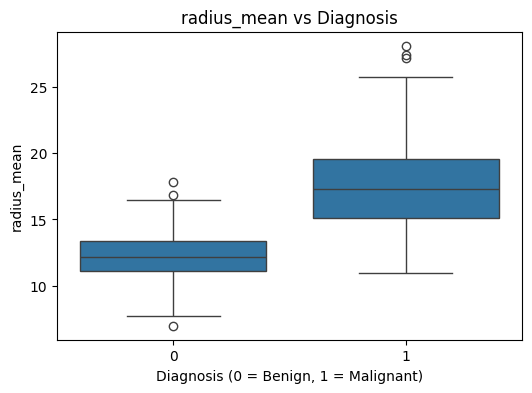

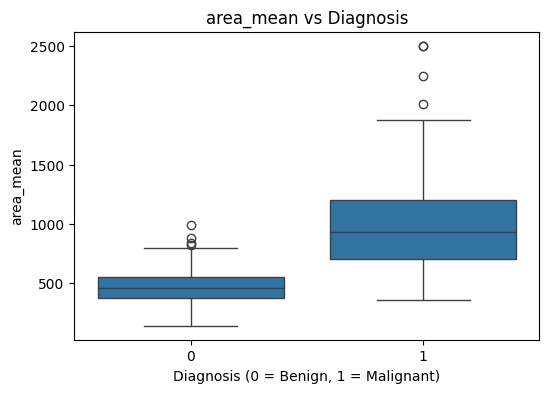

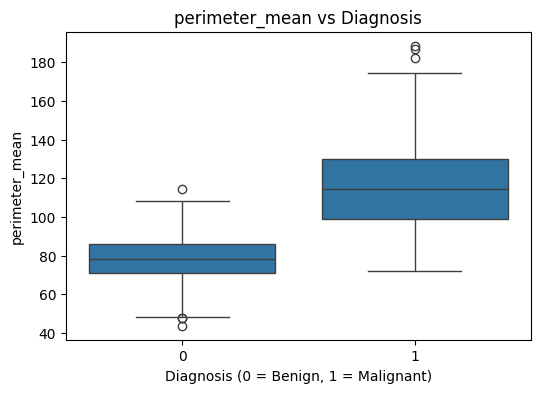

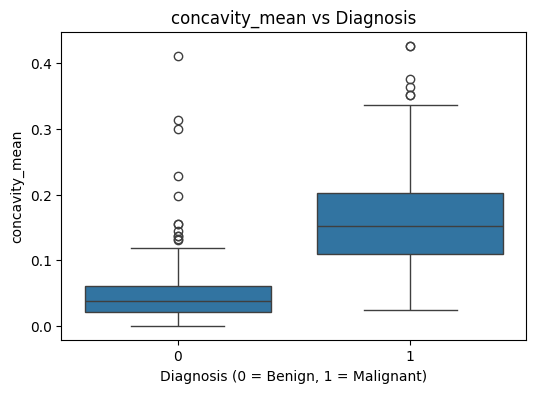

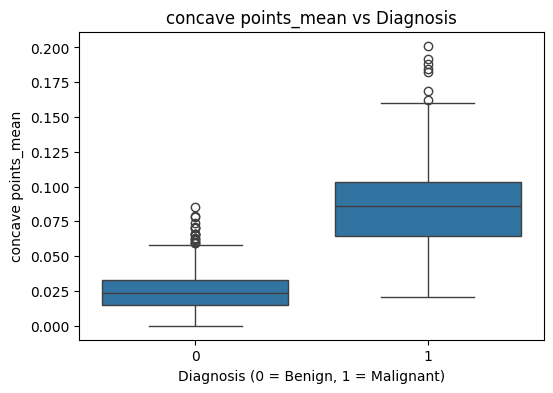

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of key features to visualize
key_features = ['radius_mean', 'area_mean', 'perimeter_mean', 'concavity_mean', 'concave points_mean']

# Loop through features and plot boxplots
for feature in key_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'{feature} vs Diagnosis')
    plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
    plt.ylabel(feature)
    plt.show()

**Correlation Analysis**

Since many features describe geometric properties of tumor cell nuclei (e.g., radius, perimeter, area), it is important to analyze correlations between variables.

Highly correlated features may introduce redundancy and multicollinearity, which can affect model stability and interpretability.

Therefore, we compute a correlation matrix to examine relationships among features.

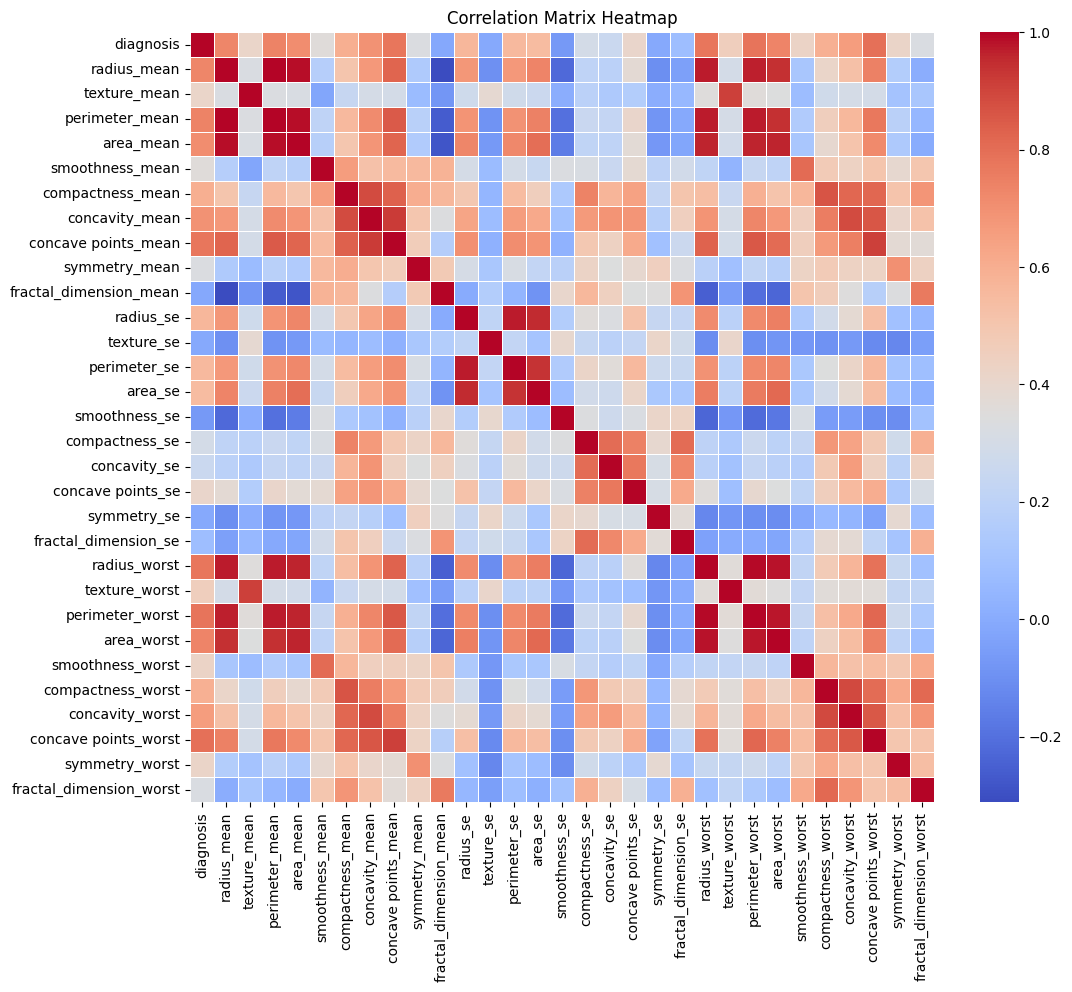

In [108]:
corr_matrix = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

**Interpretation of Correlation Results**

The correlation heatmap reveals strong positive correlations among geometric features such as radius_mean, perimeter_mean, and area_mean.

This is expected because these measurements are mathematically related. A larger tumor radius naturally leads to a larger perimeter and area.

Similar strong correlations are observed among the "_worst" versions of these features.

This indicates the presence of multicollinearity in the dataset.

**Additional Correlation Insights**

Moderate positive correlations are observed between features such as concavity_mean and concave points_mean.

These features both describe tumor boundary irregularity:

Concavity measures the depth of inward curves.

Concave points measure the number of such inward curves.

Although related, they are not mathematically dependent like geometric size features, which explains why their correlations are positive but weaker.

**Preparing Data for Modeling**

Before building a machine learning model, the dataset must be prepared by separating the predictor variables (features) from the target variable.

The data will then be split into training and testing sets to evaluate model generalization.

Stratified splitting will be used to preserve the class distribution in both sets.

In [109]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [110]:
# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


**Feature Scaling**

The dataset contains features with different numerical ranges (e.g., area values are much larger than smoothness values).

To ensure fair contribution of all features during model training, standardization is applied.

The scaler is fitted only on the training data to prevent data leakage and then applied to the test data.

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Use same transformation on test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (455, 30)
Scaled testing shape: (114, 30)


## Model Selection

Logistic Regression was used as the primary model for this classification task.

This model was chosen because:
- It is simple and easy to interpret
- It performs well for binary classification problems
- It provides probability-based predictions

In [112]:
#import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [113]:
#Create and fit model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [114]:
#Predict
y_pred = model.predict(X_test_scaled)

In [115]:
#Evaluate
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[71  1]
 [ 3 39]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Model Performance Interpretation

The Logistic Regression model achieved an accuracy of approximately **96%**, indicating a very high level of correctness in predicting tumor classifications.

This means that the model is able to correctly distinguish between malignant and benign tumors in the vast majority of cases.

In addition to accuracy, the ROC curve and AUC score were used to evaluate the model’s ability to separate the two classes. The high AUC value suggests that the model has a strong capability to differentiate between cancerous and non-cancerous cases across different classification thresholds.

Overall, the results demonstrate that Logistic Regression is highly effective for this dataset and can serve as a reliable model for breast cancer classification.

In [116]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [117]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [118]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [119]:
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.996031746031746


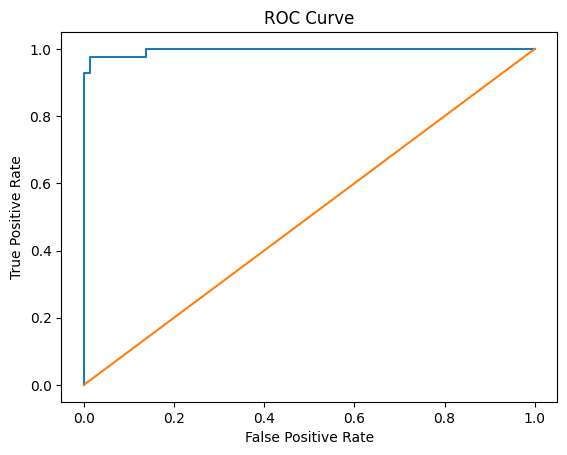

In [120]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

📈 Model Evaluation

The model was evaluated using:

Confusion Matrix

Precision

Recall

F1-score

ROC-AUC score

Recall was prioritized because false negatives (failing to detect a malignant tumor) are particularly dangerous in medical diagnosis. The ROC-AUC score was used to assess the model’s overall ability to distinguish between benign and malignant tumors across all classification thresholds.

📌 Conclusion

This project developed a Logistic Regression model to classify breast tumors as benign or malignant based on diagnostic measurements. After cleaning and preprocessing the dataset, the model was trained using 80% of the data and evaluated on 20% unseen test data.

The model achieved strong performance, with high accuracy and a strong recall score for malignant tumors. Since false negatives are particularly dangerous in medical diagnosis, recall was prioritized to ensure that most cancer cases were correctly identified. The ROC-AUC score further confirmed that the model has strong ability to distinguish between benign and malignant tumors across different classification thresholds.

Overall, Logistic Regression proved to be an effective and interpretable baseline model for binary medical classification. While the model does not replace medical professionals, it can serve as a decision-support tool to assist doctors in early cancer detection.